In [1]:
# ==============================================================================
# PIPELINE 8: Supervised Learning - Regression (Predicting Lot Prices)
# ==============================================================================
import pandas as pd

from src.training.supervised import prepare_supervised_data, tune_supervised_model
from src.training.evaluation import evaluate_regression
from src.training.visualization import plot_regression_density

pd.set_option('display.max_columns', None)

print("Loading Golden Dataset from Pipeline 5...")
df_ml = pd.read_parquet("data/prepared/ted_prepared.parquet")

Loading Golden Dataset from Pipeline 5...


In [2]:
# ------------------------------------------------------------------------------
# STEP 1: Feature Setup & Single Lot Filtering
# ------------------------------------------------------------------------------
# Filter: Regression on prices is mostly meaningful for single-lot notices to 
# avoid sum logic errors and hierarchical price distribution issues.

single_lot_mask = df_ml['LOTS_NUMBER'] <= 1.5  
df_reg = df_ml[single_lot_mask].copy()

categorical_cols = ['ISO_COUNTRY_CODE', 'CAE_TYPE', 'MAIN_ACTIVITY', 'TOP_TYPE', 'CPV', 'ID_TYPE']

# CRITICAL: We MUST remove TARGET_AWARD_VALUE_EUR and ESTIMATED_VALUE_EUR 
# from the inputs to avoid target leakage!
numeric_cols = ['NUMBER_OF_TENDERS', 'DURATION', 'PREPARATION_DAYS', 'NUTS_REGION_COUNT']

X_train, X_test, y_train, y_test, groups_train = prepare_supervised_data(
    df=df_reg,
    target_col='LOT_AWARD_VALUE_EUR',
    group_col='ID_NOTICE',
    feature_cols=categorical_cols + numeric_cols,
    test_size=0.2
)


Preparing data for supervised learning. Target: 'LOT_AWARD_VALUE_EUR'
 -> Train shape: (523815, 10), Test shape: (131340, 10)



Tuning Hyperparameters for 'LASSO' (REG)...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/home/msuess/Documents/KIDS/Project/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


 -> Optimization complete. Best parameters: {'model__alpha': 0.01}

Evaluating Lasso Regression on unseen Test Set...

--- Regression Results ---
MedAE (Robust): €127,532.33
MAE:            €1,291,599.03
RMSE:           €6,747,202.71
Adj. R-squared: -0.0088


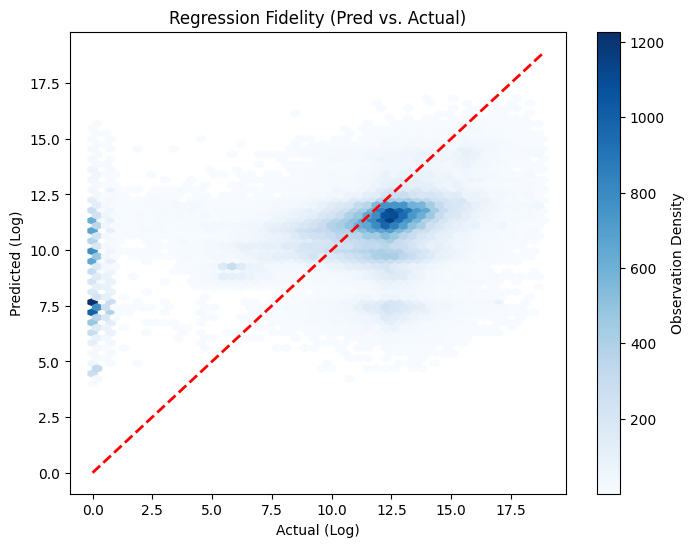

In [3]:
# ------------------------------------------------------------------------------
# STEP 2: Lasso Regression (Linear approach with automatic feature selection)
# ------------------------------------------------------------------------------
model_lasso = tune_supervised_model(
    X_train, y_train, groups_train, categorical_cols, numeric_cols, 
    model_name='lasso', task='reg', n_iter=10
)

print("\nEvaluating Lasso Regression on unseen Test Set...")
preds_lasso = model_lasso.predict(X_test)
eval_lasso = evaluate_regression(
    y_test, preds_lasso, 
    n_features=len(categorical_cols + numeric_cols), 
    is_log_transformed=True # Assuming Pipeline 5 log-transformed the prices
)
plot_regression_density(y_test, preds_lasso)

In [4]:
# ------------------------------------------------------------------------------
# STEP 3: Random Forest Regressor (Bagging Ensemble)
# ------------------------------------------------------------------------------
model_rf = tune_supervised_model(
    X_train, y_train, groups_train, categorical_cols, numeric_cols, 
    model_name='rf', task='reg', n_iter=20
)

print("\nEvaluating Random Forest on unseen Test Set...")
preds_rf = model_rf.predict(X_test)
eval_rf = evaluate_regression(
    y_test, preds_rf, 
    n_features=len(categorical_cols + numeric_cols), 
    is_log_transformed=True
)
plot_regression_density(y_test, preds_rf)


Tuning Hyperparameters for 'RF' (REG)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


/home/msuess/Documents/KIDS/Project/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=20. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
Process LokyProcess-9:
Traceback (most recent call last):
  File "/home/msuess/.pyenv/versions/3.13.13/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/msuess/.pyenv/versions/3.13.13/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/msuess/Documents/KIDS/Project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py", line 518, in _process_worker
    mem_usage = _get_memory_usage(pid, force_gc=True)
  File "/home/msuess/Documents/KIDS/Project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py", line 11

KeyboardInterrupt: 

\nEvaluating Regression Model...
 -> R² Score (Log-Scale): 0.4205
 -> RMSE (Original Scale): 6,652,594.28
 -> MAE  (Original Scale): 1,210,424.43


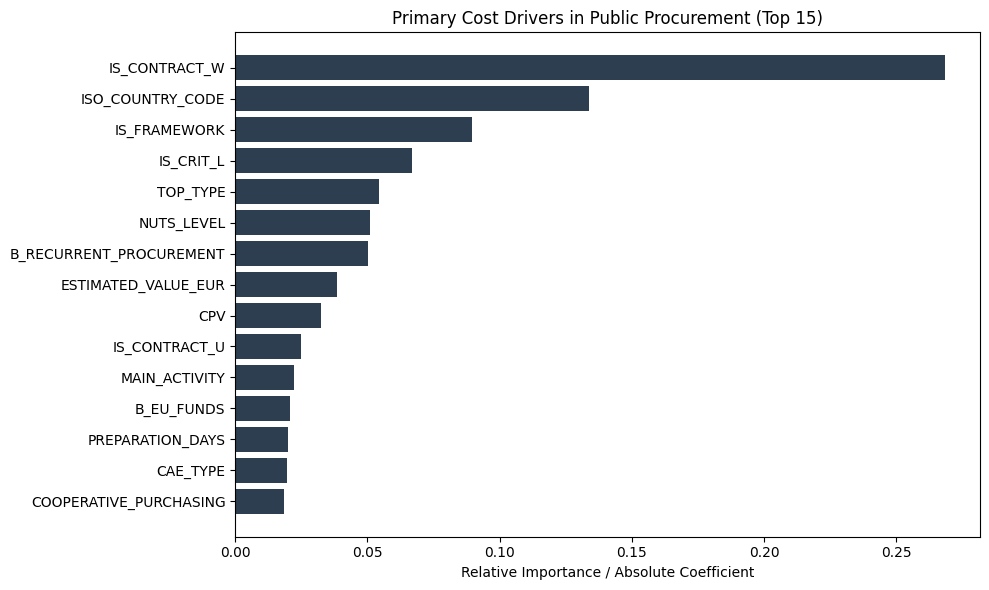

In [ ]:
# ------------------------------------------------------------------------------
# STEP 4: XGBoost Regressor (Boosting Ensemble)
# ------------------------------------------------------------------------------
model_xgb_reg = tune_supervised_model(
    X_train, y_train, groups_train, categorical_cols, numeric_cols, 
    model_name='xgboost', task='reg', n_iter=20
)

print("\nEvaluating XGBoost on unseen Test Set...")
preds_xgb_reg = model_xgb_reg.predict(X_test)
eval_xgb_reg = evaluate_regression(
    y_test, preds_xgb_reg, 
    n_features=len(categorical_cols + numeric_cols), 
    is_log_transformed=True
)
plot_regression_density(y_test, preds_xgb_reg)